In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('cleaned_data')
# apply exclusion criteria to remove outliers
df = df[~(
    (df['sbp'] < 90) | (df['sbp'] > 200) |
    (df['tc'] < 130) | (df['tc'] > 320) |
    (df['hdlc'] < 20) | (df['hdlc'] > 100) |
    (df['bmi'] < 18.5) | (df['bmi'] >= 40)
)]

df.shape

(10838, 24)

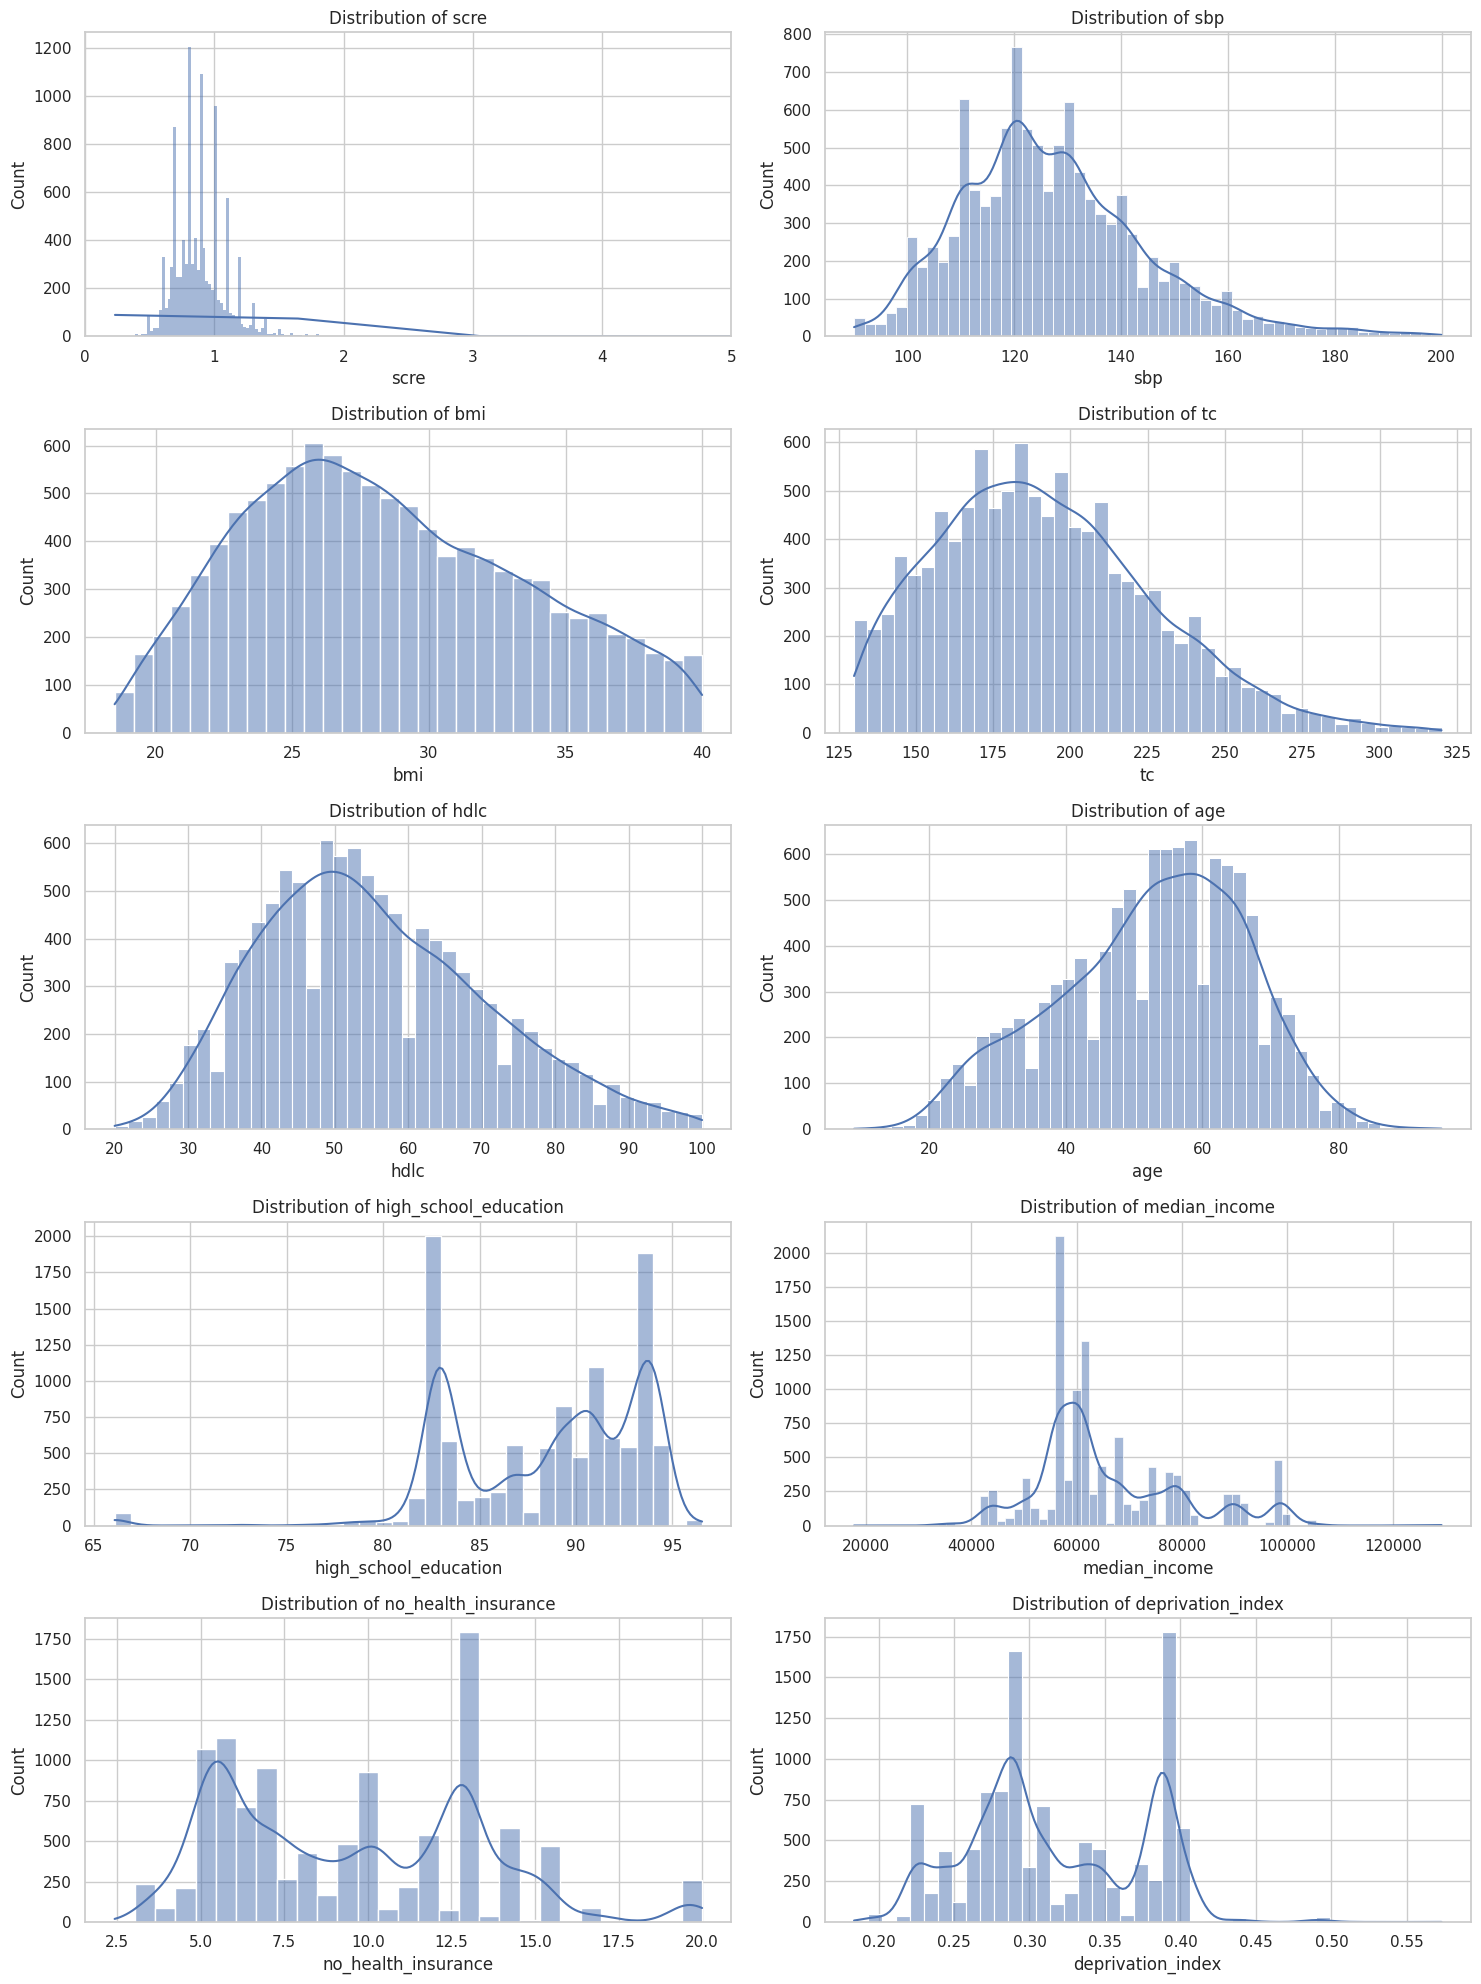

In [6]:
# load lib
import matplotlib.pyplot as plt
import seaborn as sns

# continuous and categorical columns
continuous_cols = ['scre', 'sbp', 'bmi', 'tc', 'hdlc', 'age', 'high_school_education', 
                   'median_income', 'no_health_insurance', 'deprivation_index']
categorical_cols = ['smoker', 'antihtn', 'diabetes', 'cvd', 'race', 'ethnicity', 'sex']

# set style
sns.set(style="whitegrid")

# continuous variable distributions
fig_cont, axes_cont = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes_cont = axes_cont.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col].dropna(), ax=axes_cont[i], kde=True)
    axes_cont[i].set_title(f'Distribution of {col}')
    axes_cont[i].set_xlabel(col)
    if col == 'scre':
        axes_cont[i].set_xlim(0, 5)

fig_cont.tight_layout()

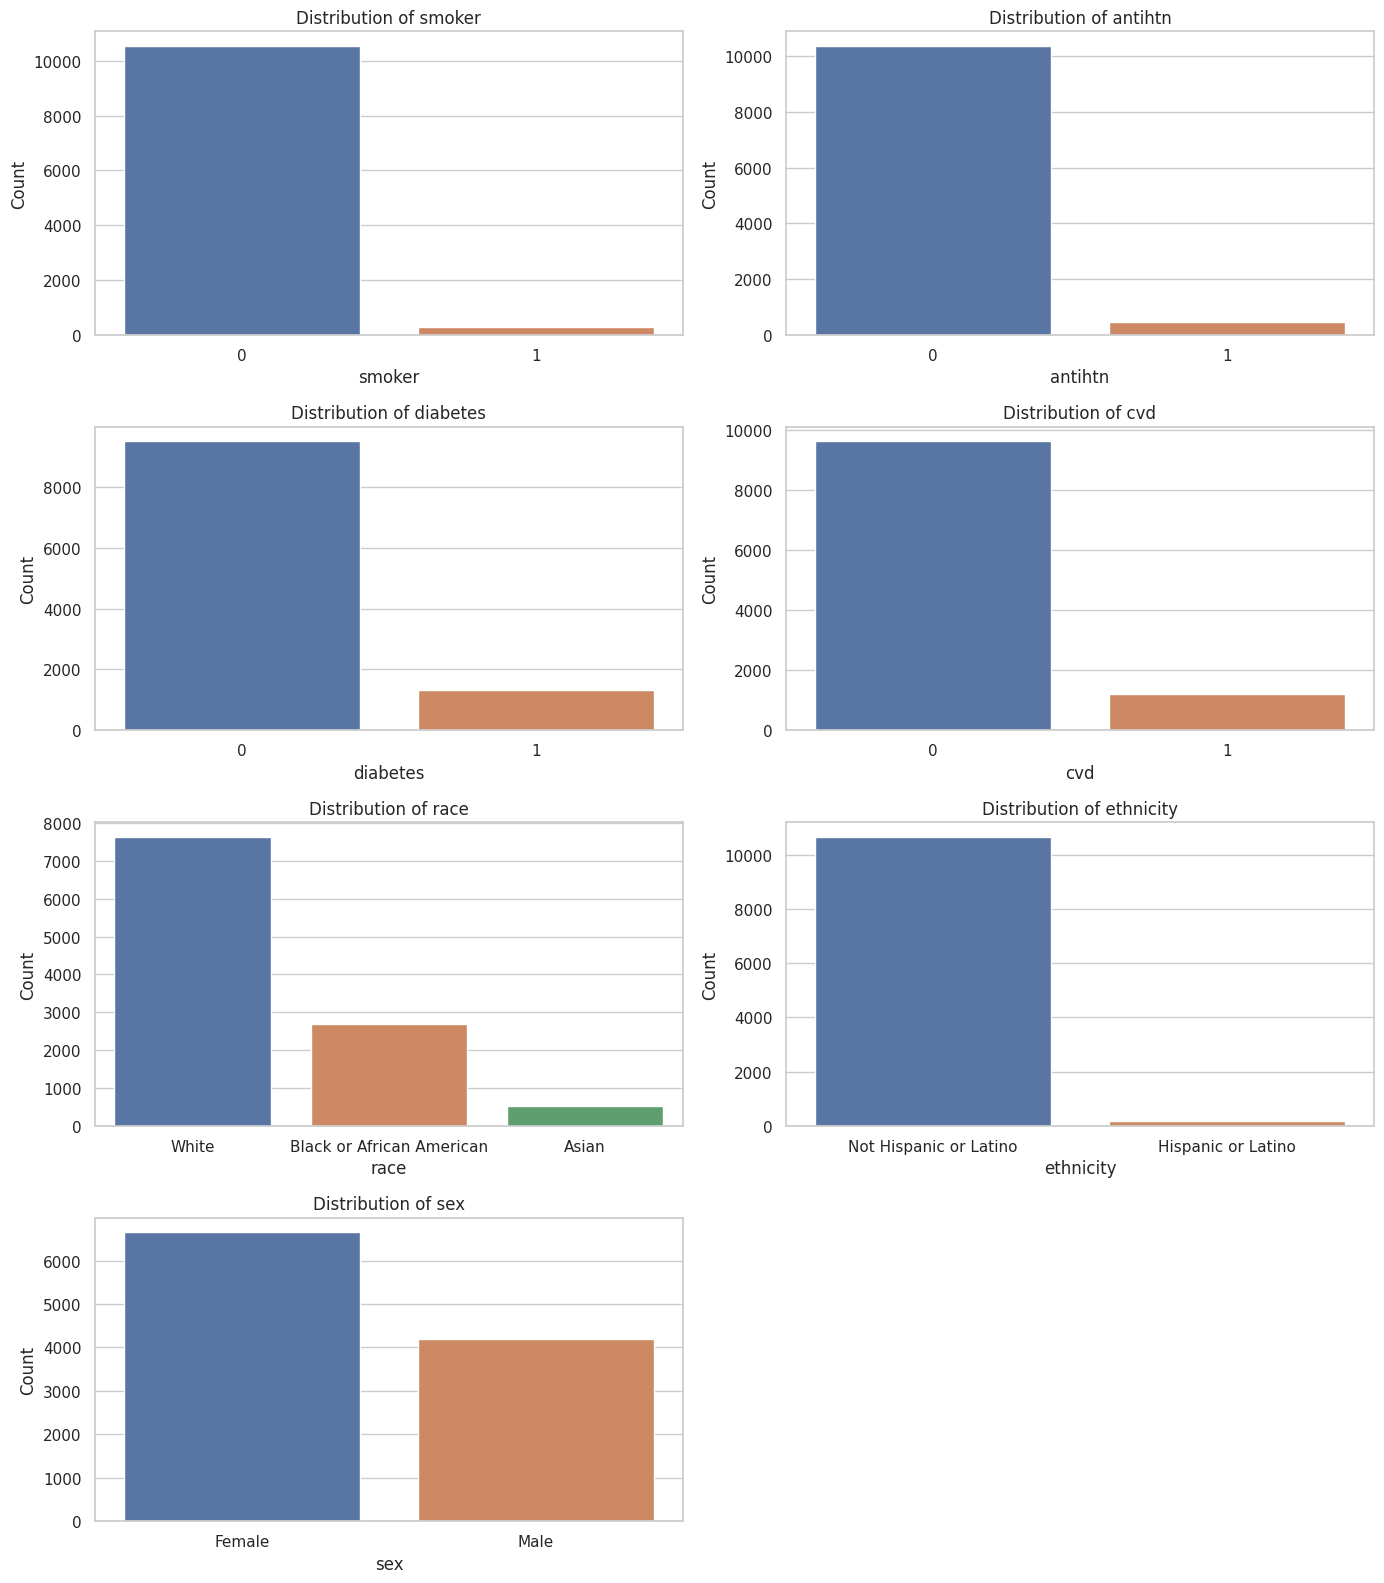

In [5]:
# categorical variable distributions
fig_cat, axes_cat = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes_cat = axes_cat.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes_cat[i], order=df[col].dropna().value_counts().index)
    axes_cat[i].set_title(f'Distribution of {col}')
    axes_cat[i].set_xlabel(col)
    axes_cat[i].set_ylabel('Count')

# Remove unused subplot if necessary
for j in range(len(categorical_cols), len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

fig_cat.tight_layout()

plt.show()

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency

# Ensure df is available (if not, please provide the dataset)
if 'df' in locals() or 'df' in globals():
    # Define numerical and categorical variables
    numerical_vars = ['scre', 'sbp', 'bmi', 'tc', 'hdlc', 'age', 
                      'high_school_education', 'median_income', 
                      'no_health_insurance', 'deprivation_index']
    categorical_vars = ['smoker', 'antihtn', 'diabetes']

    # Initialize result dictionary
    results = {}

    # Compute mean ± SD for numerical variables stratified by CVD status
    for var in numerical_vars:
        if var in df.columns:
            means_sds = df.groupby('cvd')[var].agg(['mean', 'std'])
            means_sds = means_sds.round(2)  # Round mean and SD to 2 decimal places
            means_sds['Mean±SD'] = means_sds['mean'].astype(str) + "±" + means_sds['std'].astype(str)

            # Perform t-test
            t_stat, p_value = ttest_ind(
                df[df['cvd'] == 1][var].dropna(),
                df[df['cvd'] == 0][var].dropna(),
                equal_var=False
            )
            means_sds['p-value'] = p_value
            
            # Keep only the required formatted column
            results[var] = means_sds[['Mean±SD', 'p-value']]

    # Compute count and percentage distribution for categorical variables stratified by CVD status
    for var in categorical_vars:
        if var in df.columns:
            count_table = df.groupby('cvd')[var].value_counts().unstack().fillna(0)
            percentage_table = count_table.div(count_table.sum(axis=1), axis=0) * 100
            count_percentage_table = count_table.astype(int).astype(str) + " (" + percentage_table.round(1).astype(str) + "%)"
            
            # Adding p-values using chi-square test
            chi2, p, _, _ = chi2_contingency(count_table)
            count_percentage_table['p-value'] = p
            
            results[var] = count_percentage_table

    # Convert results to DataFrame
    final_analysis_df = pd.concat(results, axis=0)

    # Format p-values
    final_analysis_df['p-value'] = final_analysis_df['p-value'].apply(lambda x: '<0.05' if x < 0.05 else '')

final_analysis_df